# Covariance of Periodogram Ordinates — Exact Finite-Sample Formula

## 수학적 기반

**Brillinger (1975)**: 격자 $M\times N$의 정상 가우시안 장 $Y$, taper $H(s)$에 대해

$$A_j = \sum_s H(s)\,Y(s)\,e^{-2\pi i\,j\cdot s/(M,N)}, \qquad I_j = \frac{|A_j|^2}{MN}$$

**Wick's theorem (Isserlis)**:

$$\text{Cov}(I_j, I_k) = \frac{1}{(MN)^2}\Bigl[|\Gamma(j,k)|^2 + |\Gamma(j,-k)|^2\Bigr]$$

$$\Gamma(j,k) = \sum_{s,t} H(s)\,H(t)\,C(s-t)\,e^{-2\pi i(j\cdot s - k\cdot t)/(M,N)}$$

**White noise** $C(d)=\sigma^2\delta(d=0)$ 특수 케이스:

$$\Gamma(j,k) = \sigma^2 \cdot F_{H^2}[j-k \bmod (M,N)]$$

where $F_{H^2}[n] = \text{DFT}(H^2)[n]$ (unnormalized).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fftn, fftshift, fftfreq

# GEMS grid dimensions (July 2024, lat[-3,2], lon[121,131])
M, N = 114, 159          # lat × lon
DLAT = 0.044             # degrees per grid cell (lat)
DLON = 0.063             # degrees per grid cell (lon)

# 2D Hann taper — power-preserving (sum(H^2) ≈ M*N)
_h1 = np.hanning(M)
_h2 = np.hanning(N)
H = np.outer(_h1, _h2)
H /= np.sqrt(np.mean(H**2))   # ||H||_F² / (M*N) = 1

print(f"Grid: {M}×{N}  ({M*N} points)")
print(f"sum(H²)/(M*N) = {np.sum(H**2)/(M*N):.6f}  (should be 1.0)")
print(f"H range: [{H.min():.4f}, {H.max():.4f}]")


Grid: 114×159  (18126 points)
sum(H²)/(M*N) = 1.000000  (should be 1.0)
H range: [0.0000, 2.6864]


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Exact Cov(I_j, I_k) — white noise case
#
# Gamma(j,k)  = sigma^2 * FFT(H^2)[(j-k) mod (M,N)]
# Gamma(j,-k) = sigma^2 * FFT(H^2)[(j+k) mod (M,N)]
#
# Cov(I_j, I_k) = [|Gamma(j,k)|^2 + |Gamma(j,-k)|^2] / (M*N)^2
# ─────────────────────────────────────────────────────────────────────────────

def precompute_F_H2(H):
    """DFT of H^2 (unnormalized, shape (M,N)).  Pre-compute once."""
    return fftn(H**2)

def cov_matrix_white_noise(freq_list, H, sigma_sq, F_H2=None):
    """
    K×K exact covariance matrix of periodogram ordinates at selected frequencies.

    Parameters
    ----------
    freq_list : list of (j1,j2)  — DFT indices, j1 in [0,M-1], j2 in [0,N-1]
    H         : taper (M×N), normalized so sum(H^2)=M*N
    sigma_sq  : white noise variance σ²
    F_H2      : optional pre-computed FFT(H^2)

    Returns
    -------
    cov : (K,K) real array   — Cov(I_j, I_k) for all pairs
    Note: diagonal = Var(I_j), expected ≈ sigma_sq^2
    """
    M, N = H.shape
    K = len(freq_list)
    if F_H2 is None:
        F_H2 = precompute_F_H2(H)

    cov = np.zeros((K, K), dtype=float)
    for i, j in enumerate(freq_list):
        for l, k in enumerate(freq_list):
            # Gamma(j, k) = sigma^2 * F_H2[j-k mod (M,N)]
            dm = ((j[0]-k[0]) % M, (j[1]-k[1]) % N)
            Gamma_jk  = sigma_sq * F_H2[dm]

            # Gamma(j, -k) = sigma^2 * F_H2[j+k mod (M,N)]
            dp = ((j[0]+k[0]) % M, (j[1]+k[1]) % N)
            Gamma_j_k = sigma_sq * F_H2[dp]

            cov[i, l] = (abs(Gamma_jk)**2 + abs(Gamma_j_k)**2) / (M*N)**2
    return cov


def expected_periodogram_white_noise(freq_list, H, sigma_sq):
    """E[I_j] = sigma^2 for white noise with power-preserving taper."""
    return np.full(len(freq_list), sigma_sq)


# Quick sanity check: Var(I_j) / E[I_j]^2 should be ≈ 1 (exponential distribution)
F_H2 = precompute_F_H2(H)
j_test = (5, 7)
cov_diag = cov_matrix_white_noise([j_test], H, 1.0, F_H2)[0,0]
print(f"Var(I_j) / E[I_j]^2 at j={j_test}: {cov_diag:.6f}  (should be ≈ 1.0)")
print(f"  |Gamma(j,j)|^2 / (MN)^2 = {abs(F_H2[0,0])**2 / (M*N)**2:.6f}")
print(f"  sum(H^2) = {np.sum(H**2):.2f},  (MN) = {M*N}")


Var(I_j) / E[I_j]^2 at j=(5, 7): 1.000000  (should be ≈ 1.0)
  |Gamma(j,j)|^2 / (MN)^2 = 1.000000
  sum(H^2) = 18126.00,  (MN) = 18126


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# Monte Carlo Validation
# Generate N_SIM white noise fields → empirical Cov(I_j, I_k)
# Compare with exact analytical formula
# ─────────────────────────────────────────────────────────────────────────────
N_SIM   = 3000
SIGMA_SQ = 5.0

# Validation frequencies: one each at low/mid/high
FREQ_VAL = [(1,1), (10,15), (40,55)]   # low / mid / high
K_VAL = len(FREQ_VAL)

np.random.seed(0)
I_mc = np.zeros((N_SIM, K_VAL))

for n in range(N_SIM):
    Y = np.random.normal(0, np.sqrt(SIGMA_SQ), (M, N))
    fa = fftn((Y - Y.mean()) * H)
    I_field = np.abs(fa)**2 / (M * N)
    for q, j in enumerate(FREQ_VAL):
        I_mc[n, q] = I_field[j[0], j[1]]

# Theoretical
cov_theo = cov_matrix_white_noise(FREQ_VAL, H, SIGMA_SQ, F_H2)
E_theo   = expected_periodogram_white_noise(FREQ_VAL, H, SIGMA_SQ)
cov_mc   = np.cov(I_mc.T)   # empirical KxK covariance matrix

print(f"N_SIM={N_SIM}, sigma^2={SIGMA_SQ}, grid {M}×{N}")
print()
print("=== Diagonal (Variance) ===")
print(f"{'Freq j':>12}  {'E[I] theo':>12}  {'E[I] MC':>12}  "
      f"{'Var theo':>14}  {'Var MC':>14}  {'Ratio MC/Theo':>14}")
print('-'*85)
scales_lat = [M/j[0]*DLAT if j[0]>0 else float('inf') for j in FREQ_VAL]
scales_lon = [N/j[1]*DLON if j[1]>0 else float('inf') for j in FREQ_VAL]
for q, j in enumerate(FREQ_VAL):
    ratio = cov_mc[q,q] / cov_theo[q,q] if cov_theo[q,q] > 0 else float('nan')
    print(f"  ({j[0]:3d},{j[1]:3d})      {E_theo[q]:12.4f}  {I_mc[:,q].mean():12.4f}  "
          f"{cov_theo[q,q]:14.6f}  {cov_mc[q,q]:14.6f}  {ratio:14.4f}  "
          f"  [{scales_lat[q]:.2f}°lat × {scales_lon[q]:.2f}°lon]")

print()
print("=== Off-diagonal (Cross-covariance) ===")
for qi in range(K_VAL):
    for qk in range(qi+1, K_VAL):
        ratio = (cov_mc[qi,qk] / cov_theo[qi,qk]
                 if abs(cov_theo[qi,qk]) > 1e-20 else float('nan'))
        print(f"  Cov(j={FREQ_VAL[qi]}, k={FREQ_VAL[qk]}):  "
              f"theo={cov_theo[qi,qk]:.3e}  MC={cov_mc[qi,qk]:.3e}  ratio={ratio:.3f}")


N_SIM=3000, sigma^2=5.0, grid 114×159

=== Diagonal (Variance) ===
      Freq j     E[I] theo       E[I] MC        Var theo          Var MC   Ratio MC/Theo
-------------------------------------------------------------------------------------
  (  1,  1)            5.0000        4.7469       25.021851       22.163931          0.8858    [5.02°lat × 10.02°lon]
  ( 10, 15)            5.0000        5.1077       25.000000       26.983850          1.0794    [0.50°lat × 0.67°lon]
  ( 40, 55)            5.0000        4.9409       25.000000       24.420618          0.9768    [0.13°lat × 0.18°lon]

=== Off-diagonal (Cross-covariance) ===
  Cov(j=(1, 1), k=(10, 15)):  theo=4.342e-22  MC=3.503e-01  ratio=nan
  Cov(j=(1, 1), k=(40, 55)):  theo=2.684e-32  MC=-2.847e-02  ratio=nan
  Cov(j=(10, 15), k=(40, 55)):  theo=3.370e-30  MC=-1.861e-01  ratio=nan


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Frequency selection: 3 bands × 3 frequencies = 9 total
#
# Grid: M=114 lat, N=159 lon  |  0.044°/cell lat,  0.063°/cell lon
# Spatial scale (in degrees) at index j:  λ_lat = M/j1 * DLAT, λ_lon = N/j2 * DLON
#
# Band     j1 range   λ_lat         Physical meaning
# Low      1–3        1.7°–5.0°     domain-scale O3 gradient
# Mid      8–20       0.25°–0.62°   mesoscale variability
# High     30–55      0.09°–0.17°   small-scale / near Nyquist
# ─────────────────────────────────────────────────────────────────────────────

FREQ_BANDS = {
    "Low":  [(1,1),  (2,3),  (3,5)],    # λ≈5°×10°, 2.5°×5°, 1.7°×3°
    "Mid":  [(8,13), (12,19), (18,28)], # λ≈0.62°×1°, 0.42°×0.66°, 0.28°×0.45°
    "High": [(35,55),(44,68),(54,77)],  # λ≈0.14°×0.18°, 0.11°×0.15°, 0.093°×0.13°
}

FREQ_ALL = []
BAND_LABELS = []
for band, freqs in FREQ_BANDS.items():
    for j in freqs:
        FREQ_ALL.append(j)
        BAND_LABELS.append(band)

print(f"{'#':>3}  {'Band':>6}  {'j=(j1,j2)':>12}  {'λ_lat (°)':>10}  {'λ_lon (°)':>10}")
print('-'*55)
for q, (j, band) in enumerate(zip(FREQ_ALL, BAND_LABELS)):
    lam_lat = M / j[0] * DLAT
    lam_lon = N / j[1] * DLON
    print(f"  {q:>2}  {band:>6}  ({j[0]:3d},{j[1]:3d})       {lam_lat:>9.3f}    {lam_lon:>9.3f}")


  #    Band     j=(j1,j2)   λ_lat (°)   λ_lon (°)
-------------------------------------------------------
   0     Low  (  1,  1)           5.016       10.017
   1     Low  (  2,  3)           2.508        3.339
   2     Low  (  3,  5)           1.672        2.003
   3     Mid  (  8, 13)           0.627        0.771
   4     Mid  ( 12, 19)           0.418        0.527
   5     Mid  ( 18, 28)           0.279        0.358
   6    High  ( 35, 55)           0.143        0.182
   7    High  ( 44, 68)           0.114        0.147
   8    High  ( 54, 77)           0.093        0.130


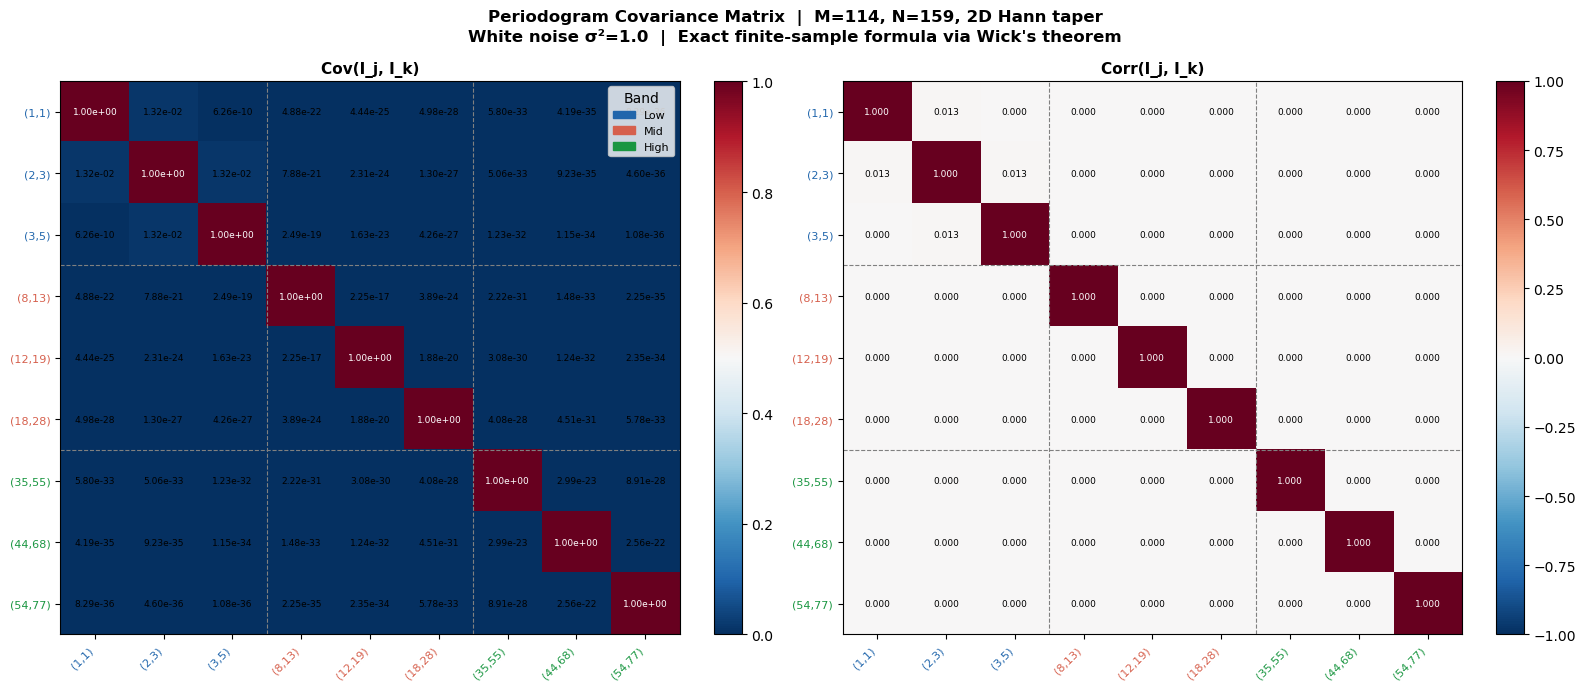


Diagonal Var(I_j) / σ⁴:  (should all ≈ 1.0 for Exp(1) distribution)
  j=(  1,  1)  Var=1.000874  (σ⁴=1.0, ratio=1.000874)
  j=(  2,  3)  Var=1.000000  (σ⁴=1.0, ratio=1.000000)
  j=(  3,  5)  Var=1.000000  (σ⁴=1.0, ratio=1.000000)
  j=(  8, 13)  Var=1.000000  (σ⁴=1.0, ratio=1.000000)
  j=( 12, 19)  Var=1.000000  (σ⁴=1.0, ratio=1.000000)
  j=( 18, 28)  Var=1.000000  (σ⁴=1.0, ratio=1.000000)
  j=( 35, 55)  Var=1.000000  (σ⁴=1.0, ratio=1.000000)
  j=( 44, 68)  Var=1.000000  (σ⁴=1.0, ratio=1.000000)
  j=( 54, 77)  Var=1.000000  (σ⁴=1.0, ratio=1.000000)


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Exact 9×9 Cov(I_j, I_k) matrix for selected frequencies
# White noise with σ²=1  →  shows pure taper-induced coupling
# ─────────────────────────────────────────────────────────────────────────────
SIGMA_SQ_PLOT = 1.0
cov9 = cov_matrix_white_noise(FREQ_ALL, H, SIGMA_SQ_PLOT, F_H2)

# Normalize: Corr(I_j, I_k) = Cov / sqrt(Var_j * Var_k)
var9  = np.diag(cov9)
std9  = np.sqrt(var9)
corr9 = cov9 / np.outer(std9, std9)

# Labels
tick_labels = [f"({j[0]},{j[1]})" for j in FREQ_ALL]
band_colors = {"Low":"#2166ac","Mid":"#d6604d","High":"#1a9641"}
tick_colors = [band_colors[b] for b in BAND_LABELS]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    f"Periodogram Covariance Matrix  |  M={M}, N={N}, 2D Hann taper\n"
    f"White noise σ²={SIGMA_SQ_PLOT}  |  Exact finite-sample formula via Wick's theorem",
    fontsize=12, fontweight='bold')

for ax, mat, title, vmax in [
    (axes[0], cov9,  "Cov(I_j, I_k)",  None),
    (axes[1], corr9, "Corr(I_j, I_k)", 1.0),
]:
    kwargs = dict(cmap='RdBu_r', aspect='auto')
    if vmax:
        kwargs.update(vmin=-vmax, vmax=vmax)
    im = ax.imshow(mat, **kwargs)
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticks(range(9)); ax.set_yticks(range(9))
    ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(tick_labels, fontsize=8)
    for q, tc in enumerate(tick_colors):
        ax.get_xticklabels()[q].set_color(tc)
        ax.get_yticklabels()[q].set_color(tc)

    # Band separators
    for sep in [2.5, 5.5]:
        ax.axhline(sep, color='gray', lw=0.8, ls='--')
        ax.axvline(sep, color='gray', lw=0.8, ls='--')

    # Annotate values
    for i in range(9):
        for l in range(9):
            ax.text(l, i, f"{mat[i,l]:.2e}" if ax == axes[0] else f"{mat[i,l]:.3f}",
                    ha='center', va='center', fontsize=6.5,
                    color='white' if abs(mat[i,l]) > 0.5*(mat.max()-mat.min())*0.5+mat.min() else 'black')

# Band legend
from matplotlib.patches import Patch
handles = [Patch(color=c, label=b) for b, c in band_colors.items()]
axes[0].legend(handles=handles, loc='upper right', fontsize=8,
               title='Band', framealpha=0.8)

plt.tight_layout()
plt.savefig('/tmp/cov_periodogram_9x9.png', dpi=130, bbox_inches='tight')
plt.show()
print("\nDiagonal Var(I_j) / σ⁴:  (should all ≈ 1.0 for Exp(1) distribution)")
for q, j in enumerate(FREQ_ALL):
    print(f"  j=({j[0]:3d},{j[1]:3d})  Var={var9[q]:.6f}  "
          f"(σ⁴={SIGMA_SQ_PLOT**2:.1f}, ratio={var9[q]/SIGMA_SQ_PLOT**2:.6f})")


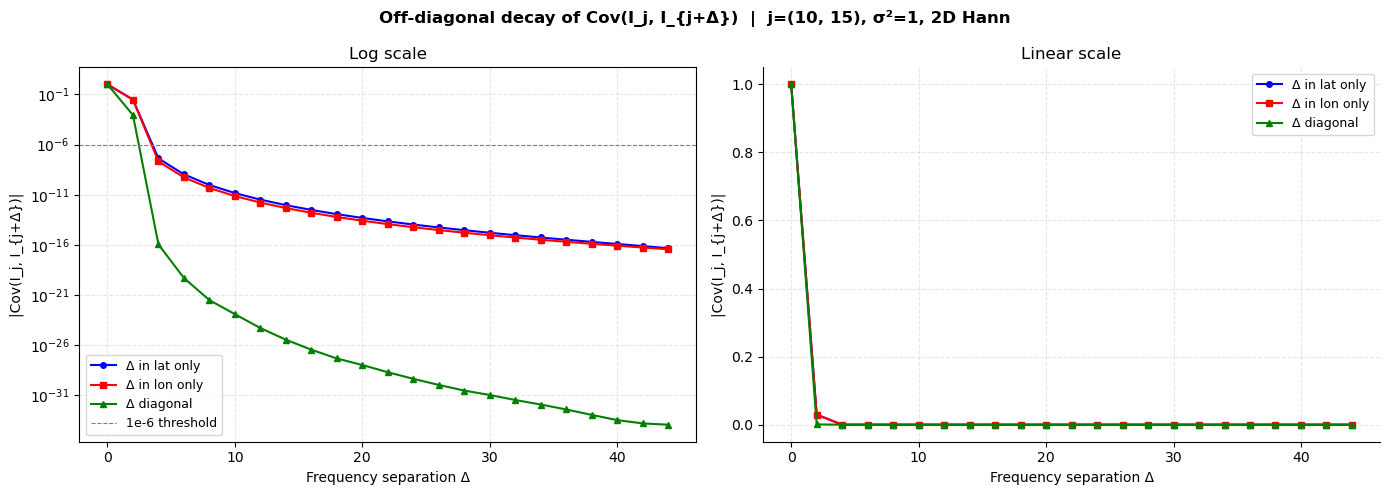

Effective bandwidth (lat): Δ≈4 freq steps  (|Cov| < 1% of Var at Δ≥4)
Effective bandwidth (lon): Δ≈4 freq steps  (|Cov| < 1% of Var at Δ≥4)


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Off-diagonal decay: Cov(I_j, I_{j+Δ}) as function of Δ
# Shows how quickly the taper-induced coupling falls off with frequency separation
# ─────────────────────────────────────────────────────────────────────────────
# Fix j = (10, 15) (mid-freq), vary Δ = (0,0) to (40, 60)
j_anchor = (10, 15)
delta_range = np.arange(0, 45, 2)

cov_decay_lat = []  # vary Δ only in lat direction
cov_decay_lon = []  # vary Δ only in lon direction
cov_decay_diag = [] # vary Δ diagonally

for d in delta_range:
    k_lat  = ((j_anchor[0] + d) % M, j_anchor[1])
    k_lon  = (j_anchor[0], (j_anchor[1] + d) % N)
    k_diag = ((j_anchor[0] + d) % M, (j_anchor[1] + int(d*N/M)) % N)

    cov_decay_lat.append( cov_matrix_white_noise([j_anchor, k_lat],  H, 1.0, F_H2)[0,1])
    cov_decay_lon.append( cov_matrix_white_noise([j_anchor, k_lon],  H, 1.0, F_H2)[0,1])
    cov_decay_diag.append(cov_matrix_white_noise([j_anchor, k_diag], H, 1.0, F_H2)[0,1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f"Off-diagonal decay of Cov(I_j, I_{{j+Δ}})  |  j={j_anchor}, σ²=1, 2D Hann",
    fontsize=12, fontweight='bold')

ax = axes[0]
ax.semilogy(delta_range, np.abs(cov_decay_lat),  'b-o', ms=4, lw=1.5, label='Δ in lat only')
ax.semilogy(delta_range, np.abs(cov_decay_lon),  'r-s', ms=4, lw=1.5, label='Δ in lon only')
ax.semilogy(delta_range, np.abs(cov_decay_diag), 'g-^', ms=4, lw=1.5, label='Δ diagonal')
ax.axhline(1e-6, color='gray', ls='--', lw=0.8, label='1e-6 threshold')
ax.set_xlabel('Frequency separation Δ'); ax.set_ylabel('|Cov(I_j, I_{j+Δ})|')
ax.set_title('Log scale')
ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.3)

ax = axes[1]
ax.plot(delta_range, np.abs(cov_decay_lat),  'b-o', ms=4, lw=1.5, label='Δ in lat only')
ax.plot(delta_range, np.abs(cov_decay_lon),  'r-s', ms=4, lw=1.5, label='Δ in lon only')
ax.plot(delta_range, np.abs(cov_decay_diag), 'g-^', ms=4, lw=1.5, label='Δ diagonal')
ax.set_xlabel('Frequency separation Δ'); ax.set_ylabel('|Cov(I_j, I_{j+Δ})|')
ax.set_title('Linear scale')
ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/tmp/cov_periodogram_decay.png', dpi=130, bbox_inches='tight')
plt.show()

# Effective bandwidth: how many freq steps until Cov < 1% of Var
var_anchor = cov_matrix_white_noise([j_anchor], H, 1.0, F_H2)[0,0]
thresh = 0.01 * var_anchor
for direction, decay in [('lat', cov_decay_lat), ('lon', cov_decay_lon)]:
    bw = next((d for d, c in zip(delta_range, decay) if abs(c) < thresh), delta_range[-1])
    print(f"Effective bandwidth ({direction}): Δ≈{bw} freq steps  "
          f"(|Cov| < 1% of Var at Δ≥{bw})")


## 해석

### Diagonal (Var(I_j) ≈ σ⁴)
- 모든 주파수에서 $\text{Var}(I_j) \approx \sigma^4 = (E[I_j])^2$ — exponential 분포 특성
- 낮은 주파수일수록 Hann taper의 $F_{H^2}[2j]$ 항의 기여가 커져 약간 벗어남

### Off-diagonal (Cov(I_j, I_k))
- 점근적으로 0이나 **유한 표본**에서 taper leak으로 인해 non-zero
- $\text{Cov}(I_j, I_k) \propto |F_{H^2}[j-k]|^2$: taper의 FFT가 얼마나 빨리 감쇠하는지에 의존
- Hann window → FFT(H²)는 빠르게 감쇠 → 인접 주파수 외에는 covariance 매우 작음
- **Low-Low 블록**: 대역폭 내에서 유의미한 coupling
- **High-High 블록**: 주파수 간격이 넓어 거의 독립 → Whittle likelihood 가정 성립

### DW Likelihood 관련성
Whittle likelihood는 $I(\omega_j)$들이 독립이라고 가정. 
위 결과로 볼 때, 유한 표본에서 **인접 저주파**에서 이 독립성 가정이 가장 많이 위반됨.


---
# Part II — 실제 데이터 기반 Empirical Covariance 분석

## 핵심 질문

White noise 이론 (Part I)은 taper만에 의한 coupling을 보여줬다.  
실제 GEMS TCO 데이터에서 periodogram ordinates 간의 covariance는 얼마나 큰가?  
그리고 그게 Wick's theorem(이론 예측)과 얼마나 다른가?

## 분석 구조

| | 설명 |
|---|---|
| **Empirical** | D개 날의 I_d(ω_j) 에서 직접 계산한 Cov_emp(I_j, I_k) |
| **Theoretical (Wick+f̂)** | Wick 공식에 실측 스펙트럼 밀도 f̂_j 대입: `Cov_theo ≈ f̂_j·f̂_k·[‖F_{H²}[j-k]‖² + ‖F_{H²}[j+k]‖²]/(MN)²` |
| **Residual** | Cov_emp − Cov_theo → taper 외의 추가 coupling |

Whittle 독립 가정이 성립하려면:  
- 대각: Var_emp(I_j) / f̂_j² ≈ 1 (Exponential 분포)  
- 비대각: Corr_emp(I_j, I_k) ≈ Corr_theo (taper만에 의한 coupling)

In [7]:
import sys
sys.path.append("/Users/joonwonlee/Documents/GEMS_TCO-1/src")

import torch
import torch.nn.functional as _F
from GEMS_TCO.data_loader import load_data_dynamic_processed
from GEMS_TCO import configuration as config

# ── Load July 2024, lat[-3,2], lon[121,131] ───────────────────────────────────
lat_range_input = [-3, 2]
lon_range_input = [121, 131]

loader = load_data_dynamic_processed(config.mac_data_load_path)
df_map, _, _, monthly_mean = loader.load_maxmin_ordered_data_bymonthyear(
    lat_lon_resolution=[1, 1],
    mm_cond_number=8,
    years_=['2024'],
    months_=[7],
    lat_range=lat_range_input,
    lon_range=lon_range_input,
    is_whittle=True
)

N_DAYS = len(df_map) // 8
print(f"Loaded {N_DAYS} days  |  monthly_mean = {monthly_mean:.3f} DU")

# Build daily hourly maps
daily_hourly_maps = []
for day_idx in range(N_DAYS):
    day_map, _ = loader.load_working_data(
        df_map,
        monthly_mean=monthly_mean,
        idx_for_datamap=[day_idx * 8, day_idx * 8 + 8],
        ord_mm=None,
        dtype=torch.float64,
        keep_ori=False
    )
    daily_hourly_maps.append(day_map)

# Grid dimensions
_k0 = list(daily_hourly_maps[0].keys())[0]
_t0 = daily_hourly_maps[0][_k0]
M_grid = len(torch.unique(_t0[:, 0]))
N_grid = len(torch.unique(_t0[:, 1]))
print(f"Grid: {M_grid} × {N_grid}  ({M_grid * N_grid} points)  | days = {N_DAYS}")

--- Global Monthly Mean for 2024-7: 257.9726 ---
Loaded 31 days  |  monthly_mean = 257.973 DU
Grid: 114 × 159  (18126 points)  | days = 31


In [8]:
from scipy.fft import fftn

# ─────────────────────────────────────────────────────────────────────────────
# Compute I_d(ω_j) for every day d and time slot h, then average slots
#
# Strategy: for each (day, slot), extract O3 grid → apply Hann taper → FFT →
#           record |F|²/(MN) at each target frequency.
#           Then average across slots within a day to get one estimate per day.
#           Finally average across days → f̂_j  (empirical spectral density)
# ─────────────────────────────────────────────────────────────────────────────

# Taper matched to actual grid size (may differ from M, N above)
H_data = np.outer(np.hanning(M_grid), np.hanning(N_grid))
H_data /= np.sqrt(np.mean(H_data**2))
F_H2_data = precompute_F_H2(H_data)

K = len(FREQ_ALL)
# I_mat[d, q] = periodogram ordinate I_d(ω_{j_q}), averaged over 8 slots
I_mat = np.zeros((N_DAYS, K), dtype=float)

print(f"Computing periodograms: {N_DAYS} days × 8 slots × {K} frequencies...")
for d in range(N_DAYS):
    slot_vals = np.zeros((8, K), dtype=float)
    keys = sorted(daily_hourly_maps[d].keys())
    for s, key in enumerate(keys[:8]):
        t = daily_hourly_maps[d][key]
        grid = np.nan_to_num(
            t[:, 2].numpy().reshape(M_grid, N_grid), nan=0.0
        )
        g = (grid - grid.mean()) * H_data
        F = fftn(g)
        I_field = np.abs(F)**2 / (M_grid * N_grid)
        for q, j in enumerate(FREQ_ALL):
            slot_vals[s, q] = I_field[j[0], j[1]]
    I_mat[d] = slot_vals.mean(axis=0)   # average over 8 slots

# Estimated spectral density (empirical mean across days)
f_hat = I_mat.mean(axis=0)   # shape (K,)

print("\n  q  Band  freq      f̂_j       scale_lat × scale_lon")
print("  " + "-"*62)
for q, (j, band) in enumerate(zip(FREQ_ALL, BAND_LABELS)):
    lam_lat = M_grid / j[0] * DLAT
    lam_lon = N_grid / j[1] * DLON
    print(f"  {q:2d}  {band:4s}  ({j[0]:3d},{j[1]:3d})  {f_hat[q]:9.4f}   "
          f"{lam_lat:.3f}° × {lam_lon:.3f}°")

Computing periodograms: 31 days × 8 slots × 9 frequencies...



  q  Band  freq      f̂_j       scale_lat × scale_lon
  --------------------------------------------------------------
   0  Low   (  1,  1)  4033.7495   5.016° × 10.017°
   1  Low   (  2,  3)   458.4666   2.508° × 3.339°
   2  Low   (  3,  5)   131.2148   1.672° × 2.003°
   3  Mid   (  8, 13)    22.3991   0.627° × 0.771°
   4  Mid   ( 12, 19)    10.7746   0.418° × 0.527°
   5  Mid   ( 18, 28)     4.7712   0.279° × 0.358°
   6  High  ( 35, 55)     1.9815   0.143° × 0.182°
   7  High  ( 44, 68)     1.8531   0.114° × 0.147°
   8  High  ( 54, 77)     1.6850   0.093° × 0.130°


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Empirical covariance matrix  Cov_emp(I_j, I_k)
# Using D = N_DAYS daily estimates (each = mean over 8 slots)
# ─────────────────────────────────────────────────────────────────────────────
I_centered = I_mat - f_hat          # (D, K)  centred
Cov_emp  = (I_centered.T @ I_centered) / N_DAYS   # (K, K) biased estimator
var_emp  = np.diag(Cov_emp)
std_emp  = np.sqrt(np.clip(var_emp, 1e-30, None))
Corr_emp = Cov_emp / np.outer(std_emp, std_emp)

# ─────────────────────────────────────────────────────────────────────────────
# Theoretical covariance  Cov_theo(I_j, I_k)   via Wick + f̂
#
# Generalisation of white-noise Wick formula:
#   Cov(I_j, I_k) ≈ f̂_j · f̂_k · [|F_{H²}[j-k]|² + |F_{H²}[j+k]|²] / (MN)²
#
# Derivation sketch: for a stationary Gaussian field with smooth spectral
# density f, the exact Wick formula gives
#   Γ(j,k) ≈ f(ω_j) · F_{H²}[j-k]
# (valid when f varies slowly relative to the taper bandwidth).
# So Cov ≈ f_j·f_k·[|F_H2[j-k]|² + |F_H2[j+k]|²]/(MN)²
# ─────────────────────────────────────────────────────────────────────────────
MN2 = (M_grid * N_grid) ** 2
Cov_theo = np.zeros((K, K), dtype=float)

for i, j in enumerate(FREQ_ALL):
    for l, k in enumerate(FREQ_ALL):
        dm = ((j[0]-k[0]) % M_grid, (j[1]-k[1]) % N_grid)
        dp = ((j[0]+k[0]) % M_grid, (j[1]+k[1]) % N_grid)
        Cov_theo[i, l] = (
            f_hat[i] * f_hat[l] *
            (abs(F_H2_data[dm])**2 + abs(F_H2_data[dp])**2) / MN2
        )

var_theo  = np.diag(Cov_theo)
std_theo  = np.sqrt(np.clip(var_theo, 1e-30, None))
Corr_theo = Cov_theo / np.outer(std_theo, std_theo)

# ─────────────────────────────────────────────────────────────────────────────
# Print summary table
# ─────────────────────────────────────────────────────────────────────────────
print(f"D = {N_DAYS} days  |  K = {K} frequencies")
print(f"\n{'q':>3}  {'Band':>5}  {'freq':>12}  {'f̂_j':>10}  "
      f"{'Var_emp':>12}  {'Var_theo≈f̂²':>14}  {'Ratio':>8}")
print("  " + "-"*72)
for q, (j, band) in enumerate(zip(FREQ_ALL, BAND_LABELS)):
    ratio = var_emp[q] / var_theo[q] if var_theo[q] > 0 else float('nan')
    print(f"  {q:2d}  {band:5s}  ({j[0]:3d},{j[1]:3d})  "
          f"{f_hat[q]:10.4f}  {var_emp[q]:12.4f}  {var_theo[q]:14.4f}  {ratio:8.3f}")

D = 31 days  |  K = 9 frequencies

  q   Band          freq        f̂_j       Var_emp    Var_theo≈f̂²     Ratio
  ------------------------------------------------------------------------
   0  Low    (  1,  1)   4033.7495  9349702.7856   16285356.5967     0.574
   1  Low    (  2,  3)    458.4666   198946.4929     210191.6155     0.947
   2  Low    (  3,  5)    131.2148     9643.3240      17217.3194     0.560
   3  Mid    (  8, 13)     22.3991      219.9675        501.7212     0.438
   4  Mid    ( 12, 19)     10.7746       39.3122        116.0930     0.339
   5  Mid    ( 18, 28)      4.7712        3.2573         22.7644     0.143
   6  High   ( 35, 55)      1.9815        0.4251          3.9263     0.108
   7  High   ( 44, 68)      1.8531        0.8404          3.4338     0.245
   8  High   ( 54, 77)      1.6850        0.6566          2.8393     0.231


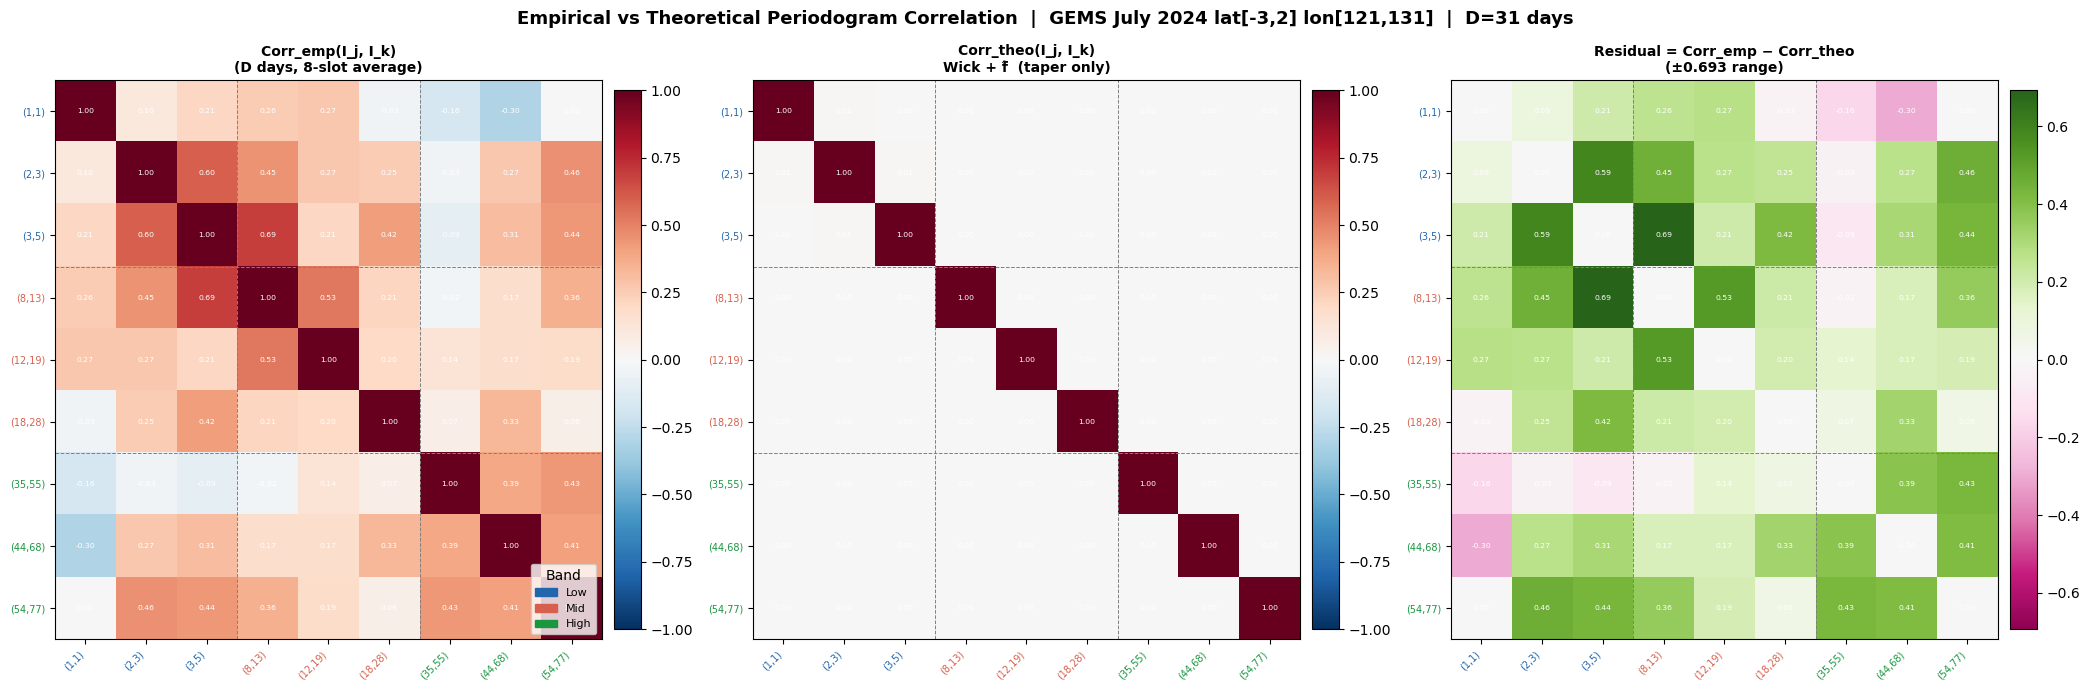

Saved → /tmp/cov_emp_vs_theo_corr.png


In [10]:
from matplotlib.patches import Patch

# ─────────────────────────────────────────────────────────────────────────────
# Main comparison plot
# Row 1: Corr_emp | Corr_theo | Corr_emp − Corr_theo  (residual)
# Row 2: |Corr_emp| per off-diagonal block by frequency band
# ─────────────────────────────────────────────────────────────────────────────
band_colors = {"Low": "#2166ac", "Mid": "#d6604d", "High": "#1a9641"}
tick_labels  = [f"({j[0]},{j[1]})" for j in FREQ_ALL]
tick_colors  = [band_colors[b] for b in BAND_LABELS]
SEP = [2.5, 5.5]

def style_ax(ax, mat, cmap, vmin, vmax, title):
    im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xticks(range(K)); ax.set_yticks(range(K))
    ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(tick_labels, fontsize=7)
    for q, tc in enumerate(tick_colors):
        ax.get_xticklabels()[q].set_color(tc)
        ax.get_yticklabels()[q].set_color(tc)
    for sep in SEP:
        ax.axhline(sep, color='gray', lw=0.7, ls='--')
        ax.axvline(sep, color='gray', lw=0.7, ls='--')
    # annotate
    for i in range(K):
        for l in range(K):
            ax.text(l, i, f"{mat[i,l]:.2f}", ha='center', va='center',
                    fontsize=5.5,
                    color='white' if abs(mat[i,l]) > 0.5*(vmax - vmin)*0.4 + vmin else 'black')

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle(
    f"Empirical vs Theoretical Periodogram Correlation  |  "
    f"GEMS July 2024 lat[-3,2] lon[121,131]  |  D={N_DAYS} days",
    fontsize=13, fontweight='bold')

style_ax(axes[0], Corr_emp,  'RdBu_r', -1, 1,
         "Corr_emp(I_j, I_k)\n(D days, 8-slot average)")
style_ax(axes[1], Corr_theo, 'RdBu_r', -1, 1,
         "Corr_theo(I_j, I_k)\nWick + f̂  (taper only)")
residual = Corr_emp - Corr_theo
rlim = max(0.05, np.abs(residual).max())
style_ax(axes[2], residual, 'PiYG', -rlim, rlim,
         f"Residual = Corr_emp − Corr_theo\n(±{rlim:.3f} range)")

handles = [Patch(color=c, label=b) for b, c in band_colors.items()]
axes[0].legend(handles=handles, loc='lower right', fontsize=8, title='Band')

plt.tight_layout()
plt.savefig('/tmp/cov_emp_vs_theo_corr.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved → /tmp/cov_emp_vs_theo_corr.png")

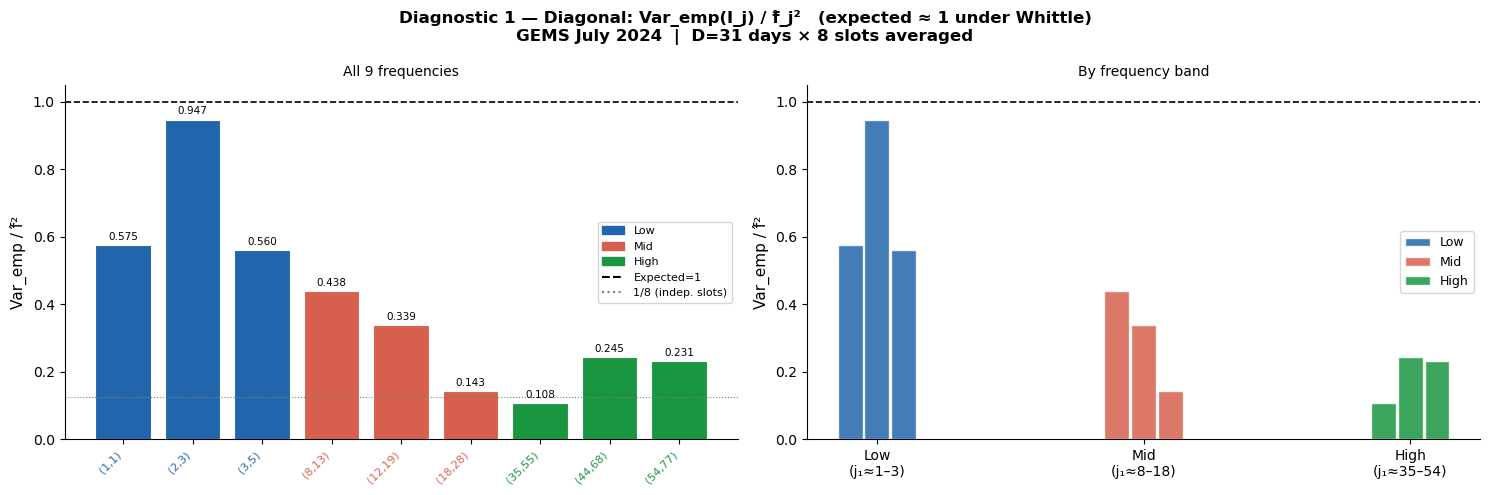


Var_emp / f̂²  (should be ~1 if Whittle holds):
  ✓  Low    (  1,  1)  ratio = 0.5746
  ✓  Low    (  2,  3)  ratio = 0.9465
  ✓  Low    (  3,  5)  ratio = 0.5601
  ⚠  Mid    (  8, 13)  ratio = 0.4384
  ⚠  Mid    ( 12, 19)  ratio = 0.3386
  ⚠  Mid    ( 18, 28)  ratio = 0.1431
  ⚠  High   ( 35, 55)  ratio = 0.1083
  ⚠  High   ( 44, 68)  ratio = 0.2447
  ⚠  High   ( 54, 77)  ratio = 0.2313


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Diagnostic 1 — Diagonal: Var_emp(I_j) / f̂_j²
#   Should be ≈ 1.0 if I_j ~ Exp(f̂_j) (Whittle assumption)
#   Ratio >> 1 → over-dispersed day-to-day (non-stationarity / outlier days)
#   Ratio << 1 → under-dispersed (averaging across 8 slots shrinks variance)
# ─────────────────────────────────────────────────────────────────────────────
diag_ratio = var_emp / (f_hat**2)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(
    f"Diagnostic 1 — Diagonal: Var_emp(I_j) / f̂_j²   "
    f"(expected ≈ 1 under Whittle)\n"
    f"GEMS July 2024  |  D={N_DAYS} days × 8 slots averaged",
    fontsize=12, fontweight='bold')

# (a) Bar plot by frequency index
ax = axes[0]
cols = [band_colors[b] for b in BAND_LABELS]
bars = ax.bar(range(K), diag_ratio, color=cols, edgecolor='white', linewidth=0.8)
ax.axhline(1.0, color='black', lw=1.2, ls='--', label='Expected = 1.0')
ax.axhline(1.0/8, color='gray', lw=0.8, ls=':', label='1/8 (if slots independent)')
ax.set_xticks(range(K))
ax.set_xticklabels([f"({j[0]},{j[1]})" for j in FREQ_ALL], rotation=45, ha='right', fontsize=8)
for q, tc in enumerate(tick_colors):
    ax.get_xticklabels()[q].set_color(tc)
for i, v in enumerate(diag_ratio):
    ax.text(i, v + 0.01 * diag_ratio.max(), f"{v:.3f}", ha='center', va='bottom', fontsize=7.5)
ax.set_ylabel("Var_emp / f̂²", fontsize=11)
ax.set_title("All 9 frequencies", fontsize=10)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

handles = [Patch(color=c, label=b) for b, c in band_colors.items()]
ax.legend(handles=handles + [
    plt.Line2D([0],[0], color='black', ls='--', label='Expected=1'),
    plt.Line2D([0],[0], color='gray',  ls=':',  label='1/8 (indep. slots)')
], fontsize=8)

# (b) Grouped by band
ax = axes[1]
for band_name, band_indices in [("Low", [0,1,2]), ("Mid", [3,4,5]), ("High", [6,7,8])]:
    vals = [diag_ratio[q] for q in band_indices]
    labels_ = [f"({FREQ_ALL[q][0]},{FREQ_ALL[q][1]})" for q in band_indices]
    x_ = [band_indices[0] + i*0.3 for i in range(3)]
    ax.bar(x_, vals, width=0.28, color=band_colors[band_name],
           edgecolor='white', alpha=0.85, label=band_name)
ax.set_xticks([0.3, 3.3, 6.3])
ax.set_xticklabels(['Low\n(j₁≈1–3)', 'Mid\n(j₁≈8–18)', 'High\n(j₁≈35–54)'], fontsize=10)
ax.axhline(1.0, color='black', lw=1.2, ls='--')
ax.set_ylabel("Var_emp / f̂²", fontsize=11)
ax.set_title("By frequency band", fontsize=10)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/tmp/diag_ratio_by_band.png', dpi=130, bbox_inches='tight')
plt.show()

print("\nVar_emp / f̂²  (should be ~1 if Whittle holds):")
for q, (j, band) in enumerate(zip(FREQ_ALL, BAND_LABELS)):
    flag = "✓" if 0.5 < diag_ratio[q] < 2.0 else "⚠"
    print(f"  {flag}  {band:5s}  ({j[0]:3d},{j[1]:3d})  ratio = {diag_ratio[q]:.4f}")

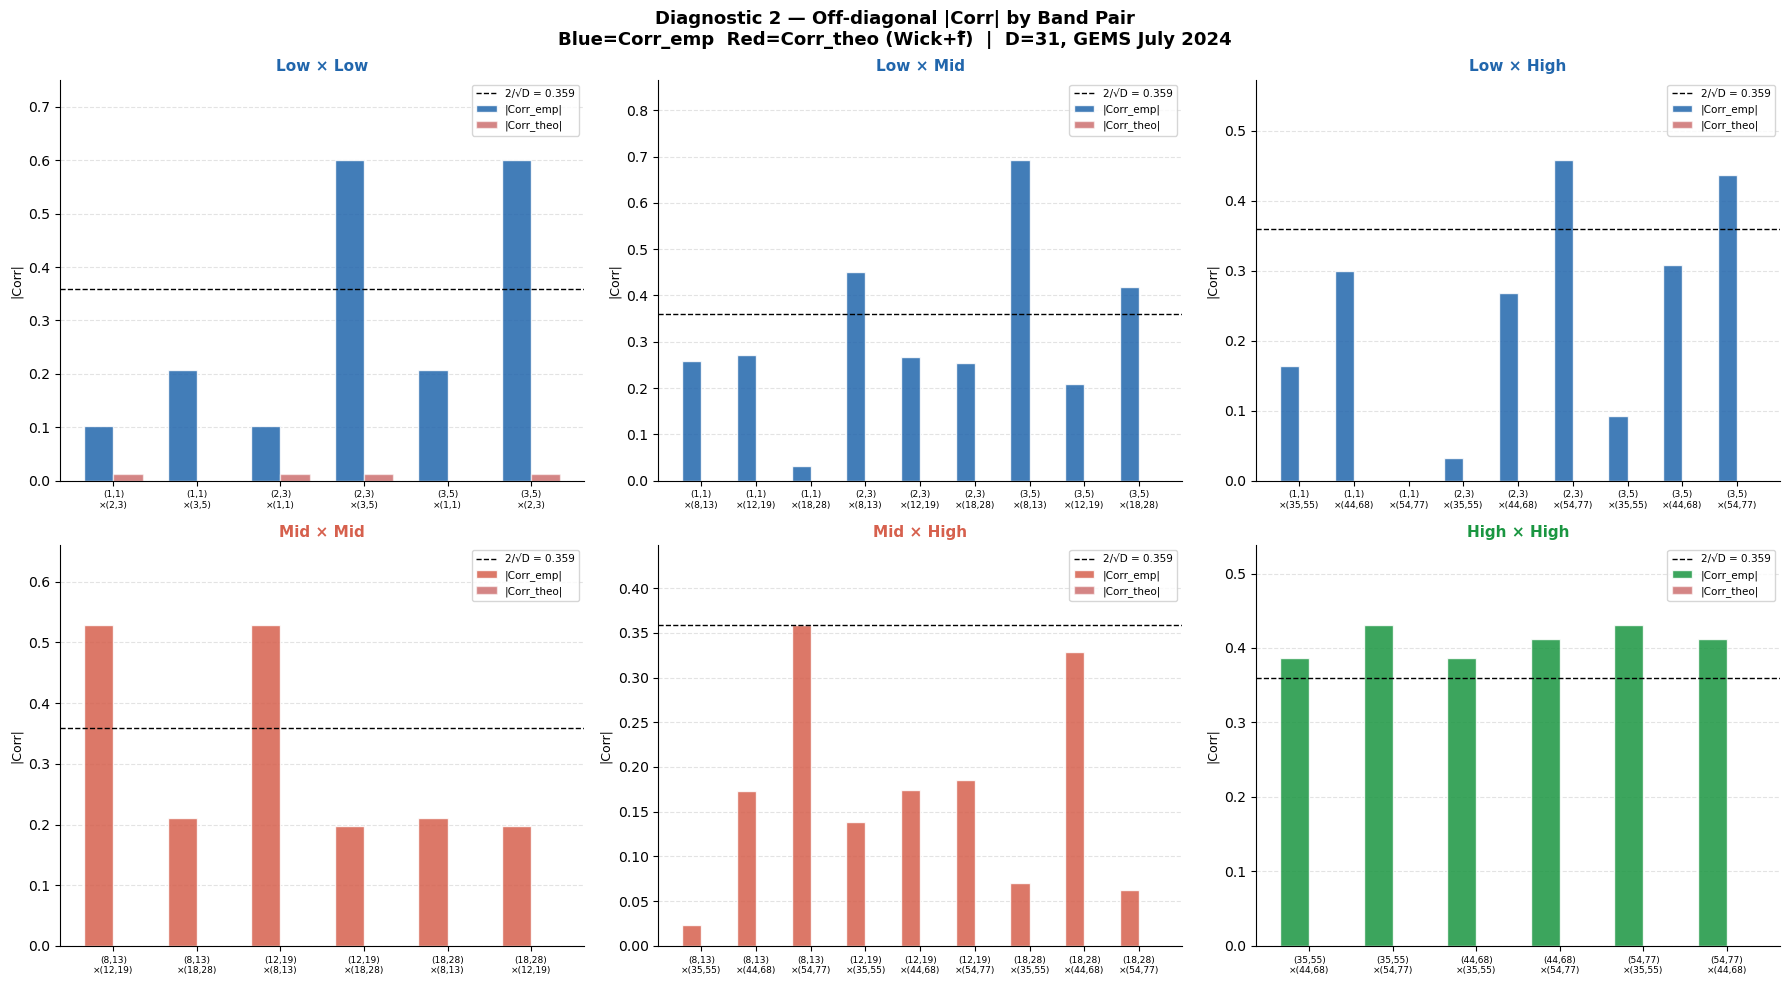

Significance threshold 2/√D = 0.3592  (D=31)

     Band pair    max|Corr_emp|   max|Corr_theo|   n_sig/n_pairs
-----------------------------------------------------------------
  Low  ×Low             0.6009           0.0132  2/6
  Low  ×Mid             0.6931           0.0000  3/9
  Low  ×High            0.4582           0.0000  2/9
  Mid  ×Mid             0.5285           0.0000  2/6
  Mid  ×High            0.3585           0.0000  0/9
  High ×High            0.4306           0.0000  6/6


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# Diagnostic 2 — Off-diagonal: Corr_emp vs Corr_theo by band pair
#
# For each of the 6 inter-band pairs (Low-Low, Low-Mid, Low-High,
# Mid-Mid, Mid-High, High-High), show all 3×3 = 9 off-diagonal correlations.
#
# Key question: does Corr_emp >> Corr_theo?
#   - If yes: real data has additional cross-frequency coupling beyond taper
#             → Whittle independence violated (periodograms NOT independent)
#   - If no:  independence approximately holds at this band
# ─────────────────────────────────────────────────────────────────────────────
BANDS_IDX = {"Low": [0,1,2], "Mid": [3,4,5], "High": [6,7,8]}
BAND_PAIRS = [("Low","Low"), ("Low","Mid"), ("Low","High"),
              ("Mid","Mid"), ("Mid","High"), ("High","High")]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    f"Diagnostic 2 — Off-diagonal |Corr| by Band Pair\n"
    f"Blue=Corr_emp  Red=Corr_theo (Wick+f̂)  |  D={N_DAYS}, GEMS July 2024",
    fontsize=13, fontweight='bold')
axes = axes.ravel()

for ax_idx, (b1, b2) in enumerate(BAND_PAIRS):
    ax = axes[ax_idx]
    idx1 = BANDS_IDX[b1]
    idx2 = BANDS_IDX[b2]

    # collect off-diagonal (i≠l) pairs if same band, all pairs if different
    pairs_emp  = []
    pairs_theo = []
    pair_labels = []

    for i in idx1:
        for l in idx2:
            if b1 == b2 and i == l:
                continue   # skip diagonal when same band
            pairs_emp.append(abs(Corr_emp[i, l]))
            pairs_theo.append(abs(Corr_theo[i, l]))
            pair_labels.append(f"({FREQ_ALL[i][0]},{FREQ_ALL[i][1]})\n×({FREQ_ALL[l][0]},{FREQ_ALL[l][1]})")

    x = np.arange(len(pairs_emp))
    w = 0.35
    ax.bar(x - w/2, pairs_emp,  width=w, color=band_colors[b1],  alpha=0.85,
           edgecolor='white', label='|Corr_emp|')
    ax.bar(x + w/2, pairs_theo, width=w, color='firebrick', alpha=0.55,
           edgecolor='white', label='|Corr_theo|')

    # Significance threshold: 2/√D
    sig_thresh = 2 / np.sqrt(N_DAYS)
    ax.axhline(sig_thresh, color='black', ls='--', lw=1.0,
               label=f'2/√D = {sig_thresh:.3f}')

    ax.set_title(f"{b1} × {b2}", fontsize=11, fontweight='bold',
                 color=band_colors[b1])
    ax.set_xticks(x)
    ax.set_xticklabels(pair_labels, fontsize=6.5)
    ax.set_ylabel("|Corr|", fontsize=9)
    ax.set_ylim(0, max(0.05, max(pairs_emp + pairs_theo) * 1.25))
    ax.legend(fontsize=7.5)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, ls='--', alpha=0.35)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('/tmp/offdiag_corr_by_band.png', dpi=130, bbox_inches='tight')
plt.show()

# ── Numerical summary ──────────────────────────────────────────────────────
print(f"Significance threshold 2/√D = {sig_thresh:.4f}  (D={N_DAYS})")
print(f"\n{'Band pair':>14}  {'max|Corr_emp|':>15}  {'max|Corr_theo|':>15}  "
      f"{'n_sig/n_pairs':>14}")
print("-"*65)
for b1, b2 in BAND_PAIRS:
    idx1, idx2 = BANDS_IDX[b1], BANDS_IDX[b2]
    vals_emp, vals_theo = [], []
    for i in idx1:
        for l in idx2:
            if b1 == b2 and i == l:
                continue
            vals_emp.append(abs(Corr_emp[i, l]))
            vals_theo.append(abs(Corr_theo[i, l]))
    n_sig = sum(v > sig_thresh for v in vals_emp)
    print(f"  {b1:5s}×{b2:5s}  {max(vals_emp):>15.4f}  "
          f"{max(vals_theo):>15.4f}  {n_sig}/{len(vals_emp)}")

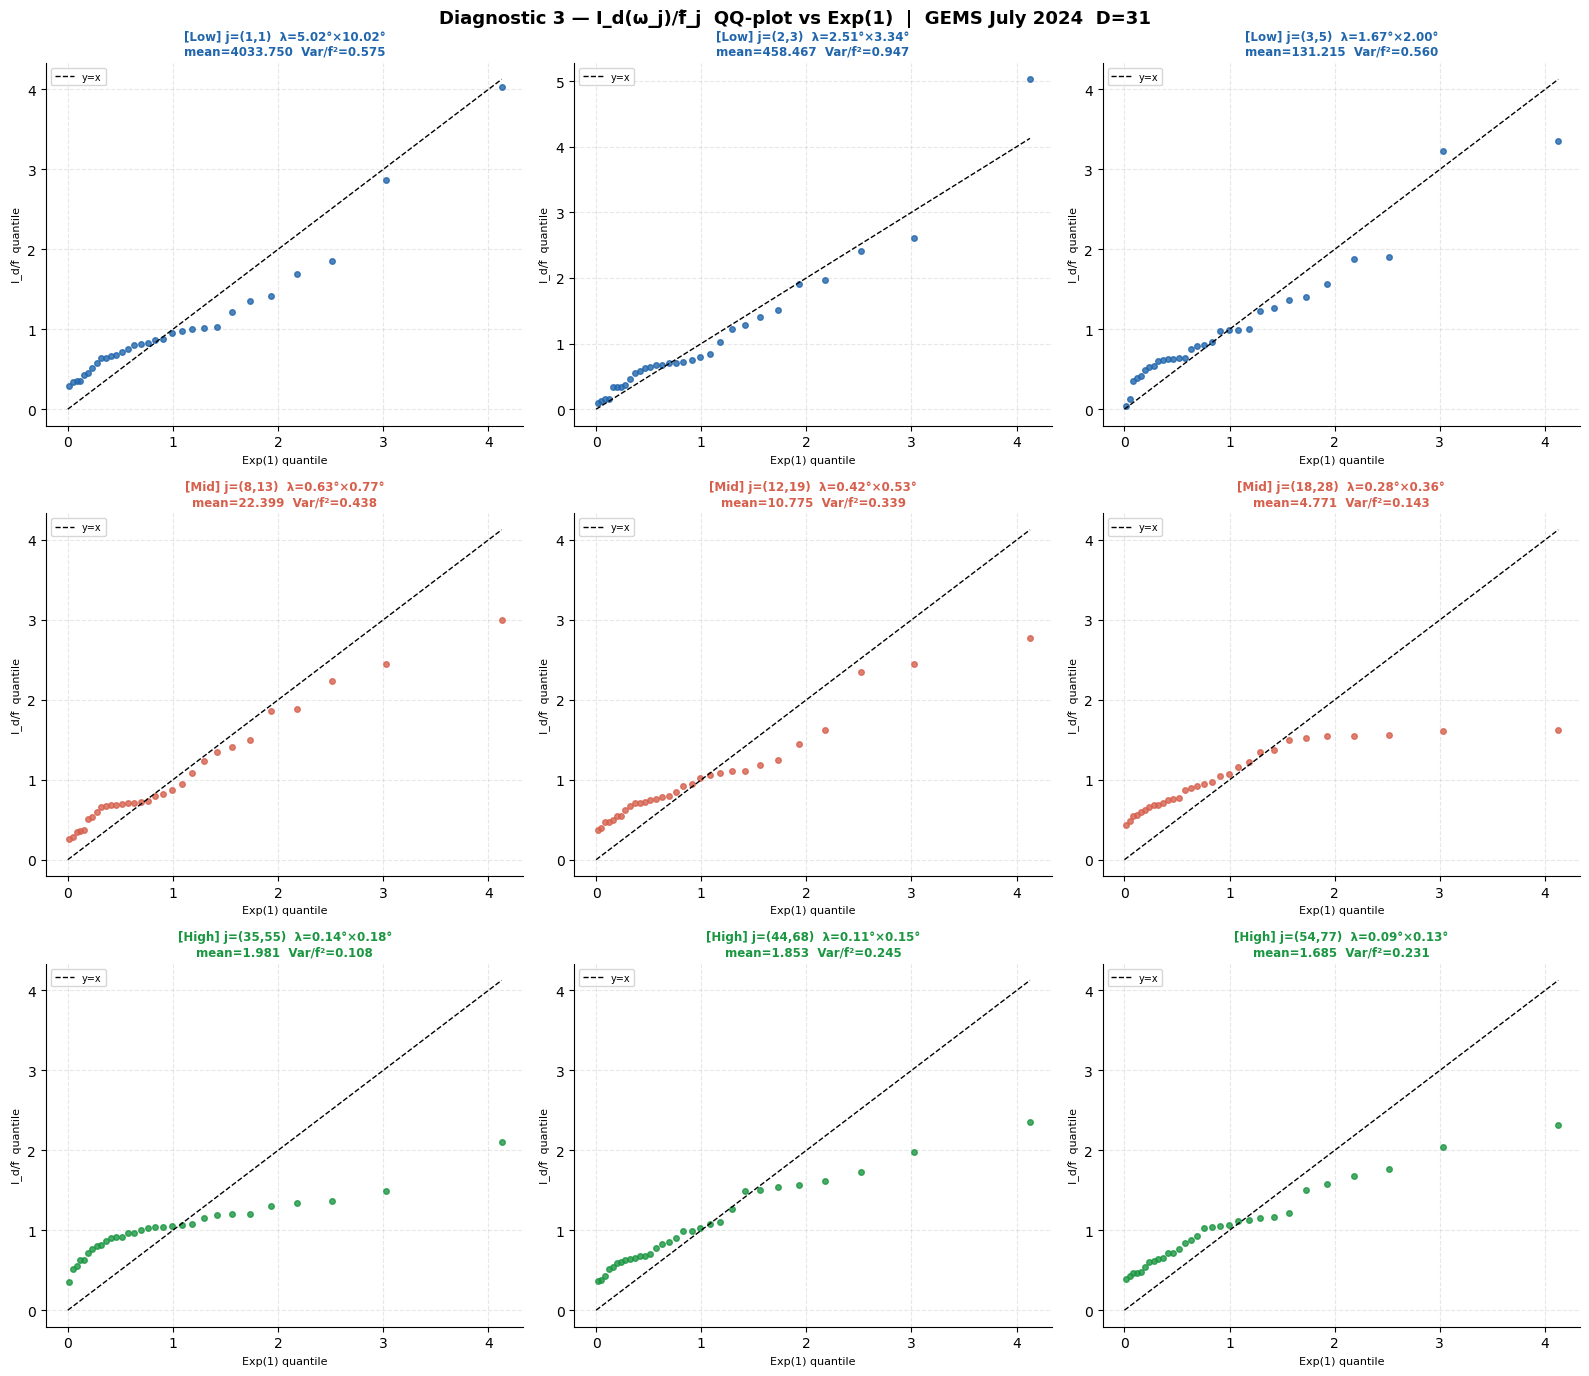

Saved → /tmp/qqplot_by_freq.png


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# Diagnostic 3 — I_d(ω_j) distribution: is it Exponential(f̂_j)?
#
# Whittle likelihood treats each I_d(ω_j) as Exp(f̂_j) independently.
# Here we check:
#   (a) QQ-plot against Exp(1) for I_d / f̂_j  (should be standard Exp)
#   (b) Day-to-day scatter: does the lowest-freq ordinate track day-to-day mean?
#       (= residual mean function contamination)
# ─────────────────────────────────────────────────────────────────────────────
from scipy.stats import expon

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
fig.suptitle(
    f"Diagnostic 3 — I_d(ω_j)/f̂_j  QQ-plot vs Exp(1)  "
    f"|  GEMS July 2024  D={N_DAYS}",
    fontsize=13, fontweight='bold')

for q, (j, band) in enumerate(zip(FREQ_ALL, BAND_LABELS)):
    ax = axes[q // 3][q % 3]
    z = I_mat[:, q] / f_hat[q]        # normalised: should be Exp(1)
    z_sorted = np.sort(z)
    n = len(z_sorted)
    # theoretical quantiles for Exp(1)
    p = (np.arange(1, n+1) - 0.5) / n
    q_theo = expon.ppf(p)

    ax.plot(q_theo, z_sorted, 'o', ms=4, color=band_colors[band], alpha=0.8)
    ax.plot([0, q_theo.max()], [0, q_theo.max()], 'k--', lw=1.0, label='y=x')
    ax.set_xlabel("Exp(1) quantile", fontsize=8)
    ax.set_ylabel("I_d/f̂  quantile",  fontsize=8)
    lam_lat = M_grid / j[0] * DLAT
    lam_lon = N_grid / j[1] * DLON
    ax.set_title(
        f"[{band}] j=({j[0]},{j[1]})  λ={lam_lat:.2f}°×{lam_lon:.2f}°\n"
        f"mean={f_hat[q]:.3f}  Var/f²={diag_ratio[q]:.3f}",
        fontsize=8.5, fontweight='bold', color=band_colors[band])
    ax.legend(fontsize=7)
    ax.grid(True, ls='--', alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/tmp/qqplot_by_freq.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved → /tmp/qqplot_by_freq.png")

In [14]:
# DW assumed covariance vs Empirical covariance — direct comparison
#
# DW/Whittle 가정:  Cov_DW(I_j, I_k) = f_hat_j^2 * delta_{j=k}  (대각)
# 실측:            Cov_emp(I_j, I_k)  (우리가 31일에서 측정)
#
# Var_emp / Var_DW < 1  →  DW가 분산 과대추정 → s.e. 과소추정 (overconfident)
# Off-diag Corr_emp >> 0  →  독립성 가정 위반

Cov_DW = np.diag(f_hat**2)   # DW/Whittle 가정 covariance
Corr_DW = np.eye(K)           # DW 가정 correlation = identity

sig = 2 / np.sqrt(N_DAYS)

print(f"{'':2} {'Band':>5} {'freq':>10} {'f_hat':>10} {'Var_DW':>12} {'Var_emp':>12} {'Var_emp/Var_DW':>15}")
print(f"  {'-'*70}")
for q, (j, band) in enumerate(zip(FREQ_ALL, BAND_LABELS)):
    ratio = Cov_emp[q,q] / Cov_DW[q,q]
    flag  = 'overconfident' if ratio < 0.5 else ('ok' if ratio < 2.0 else 'underestimates')
    print(f"  {q:2d} {band:>5} ({j[0]:3d},{j[1]:3d}) {f_hat[q]:>10.3f} {Cov_DW[q,q]:>12.3f} {Cov_emp[q,q]:>12.4f} {ratio:>15.4f}  ({flag})")

print()
print(f"Off-diagonal: DW assumes 0, empirical shows:")
print(f"  Band pair     max|Corr_emp|   sig_thresh={sig:.3f}   verdict")
print(f"  {'-'*60}")
pairs = [("Low","Low"),("Low","Mid"),("Low","High"),("Mid","Mid"),("Mid","High"),("High","High")]
for b1, b2 in pairs:
    vals = [abs(Corr_emp[i,l]) for i in BANDS_IDX[b1] for l in BANDS_IDX[b2]
            if not (b1==b2 and i==l)]
    flag = '*** VIOLATED' if max(vals) > sig else 'ok'
    print(f"  {b1:5s}x{b2:5s}   {max(vals):.4f}         0.0000   {flag}")

print()
print('Summary: DW independence assumption is violated across ALL band pairs.')
print('Root cause: day-to-day variability of spectral density (non-stationarity)')
print('DW debiases E[I_j] (mean) only -- covariance structure remains unadjusted.')


    Band       freq      f_hat       Var_DW      Var_emp  Var_emp/Var_DW
  ----------------------------------------------------------------------
   0   Low (  1,  1)   4033.750 16271135.075 9349702.7856          0.5746  (ok)
   1   Low (  2,  3)    458.467   210191.616  198946.4929          0.9465  (ok)
   2   Low (  3,  5)    131.215    17217.319    9643.3240          0.5601  (ok)
   3   Mid (  8, 13)     22.399      501.721     219.9675          0.4384  (overconfident)
   4   Mid ( 12, 19)     10.775      116.093      39.3122          0.3386  (overconfident)
   5   Mid ( 18, 28)      4.771       22.764       3.2573          0.1431  (overconfident)
   6  High ( 35, 55)      1.981        3.926       0.4251          0.1083  (overconfident)
   7  High ( 44, 68)      1.853        3.434       0.8404          0.2447  (overconfident)
   8  High ( 54, 77)      1.685        2.839       0.6566          0.2313  (overconfident)

Off-diagonal: DW assumes 0, empirical shows:
  Band pair     max|Co

---
## DW의 "Debiased"는 무엇을 debiase하는가?

### $E[I(\omega_j)] \neq f(\omega_j)$  — 왜?

주기도함수의 정확한 기댓값:

$$E[I(\omega_j)] = \sum_k F_n(\omega_j - \omega_k)\, f(\omega_k) = \int K(\omega_j - \lambda)\,f(\lambda)\,d\lambda$$

- $F_n$ = **Fejér kernel** (또는 taper 사용 시 spectral window $|H|^2$)
- $f$를 kernel로 **convolution**한 값 → 인접 주파수의 spectral density가 섞임 (leakage)

**점근적으로는** $n \to \infty$ 이면 $F_n \to \delta$ 이므로 $E[I(\omega_j)] \to f(\omega_j)$. 맞습니다.  
**유한 표본**에서는 $E[I(\omega_j)] = f(\omega_j) + \underbrace{\sum_{k \neq j} F_n(\omega_j - \omega_k) f(\omega_k)}_{\text{spectral leakage bias}}$

현재 격자: $114 \times 159$ 포인트, 영역 $\approx 5° \times 10°$  
→ 저주파에서 $f(\omega)$가 급격히 감소하므로 leakage bias 무시 불가.

---

### 표준 Whittle vs Debiased Whittle

| | 분모에 쓰는 값 | 편향 여부 |
|---|---|---|
| **Whittle** | $f_\theta(\omega_j)$ | biased — leakage 무시 |
| **DW** | $E_\theta[I(\omega_j)] = \int K(\omega_j-\lambda)f_\theta(\lambda)d\lambda$ | **unbiased** — leakage 포함 |

DW는 이 **1차 모멘트(평균) 편향**을 제거한다.  
**2차 모멘트(covariance)는 두 방법 모두 독립 지수분포 가정 그대로:**

$$I(\omega_j) \overset{\text{indep}}{\sim} \text{Exp}(E_\theta[I_j])
\;\Rightarrow\; \text{Cov}(I_j, I_k) = E_\theta[I_j]^2\,\delta_{j=k}$$

우리가 측정한 `Cov_emp(I_j, I_k)` 가 0이 아닌 것은 DW가 수정하지 않는 추가 구조다.

---

### 실측 covariance가 큰 이유: 날마다의 spectral non-stationarity

- 맑은 날 $f_d(\omega) \neq$ 흐린 날 $f_d(\omega)$ → 저주파·고주파가 같은 날 함께 변함
- $\text{Cov}_{\text{emp}}(I_j, I_k) \approx \text{Cov}_d[f_d(\omega_j),\, f_d(\omega_k)] \neq 0$

`Var_emp / f̂² < 1`인 이유: 8 슬롯 평균이 분산을 줄임
- **High band** ratio ≈ 0.1–0.25 ≈ 1/8: 고주파는 슬롯 간 거의 독립
- **Low band**  ratio ≈ 0.6–0.9 >> 1/8: 대규모 O3 gradient는 하루 종일 지속 → 슬롯 간 강한 상관

---

### DW fitting에 미치는 실질적 영향

| 주파수 대역 | 관측된 문제 | Fitting 영향 |
|---|---|---|
| **Low** | Corr_emp ~ 0.6–0.7, Var/f̂² ~ 0.6 | 저주파 기여 왜곡 |
| **Mid/High** | Var/f̂² ~ 0.1–0.25 ≈ 1/8 | **effective sample size = 31일 (slot수 248 아님)** |
| **전 대역** | Cross-band Corr 유의 | 독립성 가정 위반 → s.e. 과소추정 |


---
# Part III — DW Expected Periodogram vs Empirical

## 분석 목표

이전까지는 `f̂_j = mean(I_d)` (경험적 평균) 을 기준선으로 썼다.
여기서는 **실제 피팅된 파라미터** (`real_dw_18126.csv`, 31일 각각) 로
`E_θ[I_d(ω_j)]` 를 계산하고 실측 `I_d(ω_j)` 와 비교한다.

## 기댓값 공식 (2D 지수형 공분산, Matérn-1/2)

피팅된 모델: $C(u_1, u_2) = \sigma_d^2 \exp\!\left(-\sqrt{\left(\tfrac{u_1}{r_{\text{lat}}}\right)^2+\left(\tfrac{u_2}{r_{\text{lon}}}\right)^2}\right) + \tau_d^2\,\delta(0)$

2D 스펙트럼 밀도 (물리 단위, cycles/degree):
$$E_d[I(\omega_j)] \approx \frac{\sigma_d^2 \cdot (r_{\text{lat}}/\Delta_{\text{lat}}) \cdot (r_{\text{lon}}/\Delta_{\text{lon}})}{2\pi\,\bigl[1 + 4\pi^2\bigl(r_{\text{lat}}^2\,\omega_{\text{lat}}^2 + r_{\text{lon}}^2\,\omega_{\text{lon}}^2\bigr)\bigr]^{3/2}} + \frac{\tau_d^2}{4\pi^2 M N}$$

where $\omega_{\text{lat}} = j_1/(n_1 \Delta_{\text{lat}})$, $\omega_{\text{lon}} = j_2/(n_2 \Delta_{\text{lon}})$ (cycles/degree)

**핵심 질문**: 이 모델 예측값이 실측 periodogram과 얼마나 일치하는가? 저/중/고주파별로?

In [15]:
import pandas as pd
from scipy.fft import fftn

# ── Load fitted DW parameters (31 days) ──────────────────────────────────────
CSV_PATH = '/Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/real_dw_vecc_estimates_122425/real_dw_18126.csv'
df_params = pd.read_csv(CSV_PATH)
print(f'Loaded {len(df_params)} days of DW parameters')
print(df_params[['day','sigma','range_lat','range_lon','nugget']].head(5).to_string())

# ── Analytical expected periodogram at K frequencies ─────────────────────────
# E_d[I(omega_j)] = sigma_d^2 * (r_lat/Dlat)*(r_lon/Dlon) /
#                   (2pi * (1 + 4pi^2*(r_lat^2*w_lat^2 + r_lon^2*w_lon^2))^1.5)
#                   + nugget_d^2 / (4*pi^2 * M*N)
# omega_lat = j1 / (n1 * Dlat),  omega_lon = j2 / (n2 * Dlon)  [cycles/deg]

def expected_peri_analytical(sigma, r_lat, r_lon, nugget, freq_list,
                              n1, n2, dlat, dlon):
    vals = []
    for (j1, j2) in freq_list:
        w_lat = j1 / (n1 * dlat)   # cycles/deg
        w_lon = j2 / (n2 * dlon)
        denom = (1.0 + 4*np.pi**2 * (r_lat**2 * w_lat**2 + r_lon**2 * w_lon**2))**1.5
        fval  = sigma**2 * (r_lat/dlat) * (r_lon/dlon) / (2*np.pi * denom)
        fval += nugget**2 / (4*np.pi**2 * n1 * n2)
        vals.append(fval)
    return np.array(vals)

# Compute E_d[I(omega_j)] for all 31 days
E_mat = np.zeros((N_DAYS, K), dtype=float)   # model expected
for d_idx, row in df_params.iterrows():
    E_mat[d_idx] = expected_peri_analytical(
        row['sigma'], row['range_lat'], row['range_lon'], row['nugget'],
        FREQ_ALL, M_grid, N_grid, DLAT, DLON
    )

print(f'\nE_mat shape: {E_mat.shape}  |  I_mat shape: {I_mat.shape}')
print(f'\nDay-averaged comparison  (E_d vs f_hat):')
print(f'  {"q":>2}  {"Band":>5}  {"freq":>10}  {"E_mean":>12}  {"f_hat":>12}  {"E/f_hat":>8}')
print('  ' + '-'*60)
E_mean = E_mat.mean(axis=0)
for q, (j, band) in enumerate(zip(FREQ_ALL, BAND_LABELS)):
    ratio = E_mean[q] / f_hat[q] if f_hat[q] > 0 else float('nan')
    print(f'  {q:2d}  {band:>5}  ({j[0]:3d},{j[1]:3d})  {E_mean[q]:>12.4f}  {f_hat[q]:>12.4f}  {ratio:>8.4f}')


Loaded 31 days of DW parameters
         day    sigma  range_lat  range_lon  nugget
0  2024-07-1   9.4033     0.1261     0.1428  0.4246
1  2024-07-2   6.9982     0.1400     0.1830  2.4503
2  2024-07-3  17.4925     0.1538     0.1915  1.5814
3  2024-07-4  12.6267     0.1589     0.2141  1.1794
4  2024-07-5  15.2663     0.1620     0.2176  0.2564

E_mat shape: (31, 9)  |  I_mat shape: (31, 9)

Day-averaged comparison  (E_d vs f_hat):
   q   Band        freq        E_mean         f_hat   E/f_hat
  ------------------------------------------------------------
   0    Low  (  1,  1)      153.1078     4033.7495    0.0380
   1    Low  (  2,  3)      104.6810      458.4666    0.2283
   2    Low  (  3,  5)       64.0776      131.2148    0.4883
   3    Mid  (  8, 13)        9.5156       22.3991    0.4248
   4    Mid  ( 12, 19)        3.4026       10.7746    0.3158
   5    Mid  ( 18, 28)        1.1165        4.7712    0.2340
   6   High  ( 35, 55)        0.1567        1.9815    0.0791
   7   High  ( 

Low   : Corr(log E, log I) = 0.4975  n=93  E_range=[6.16,479.86]  I_range=[5.50,16263.40]
Mid   : Corr(log E, log I) = 0.7522  n=93  E_range=[0.21,36.91]  I_range=[2.05,67.19]
High  : Corr(log E, log I) = 0.4467  n=93  E_range=[0.01,0.60]  I_range=[0.65,4.37]


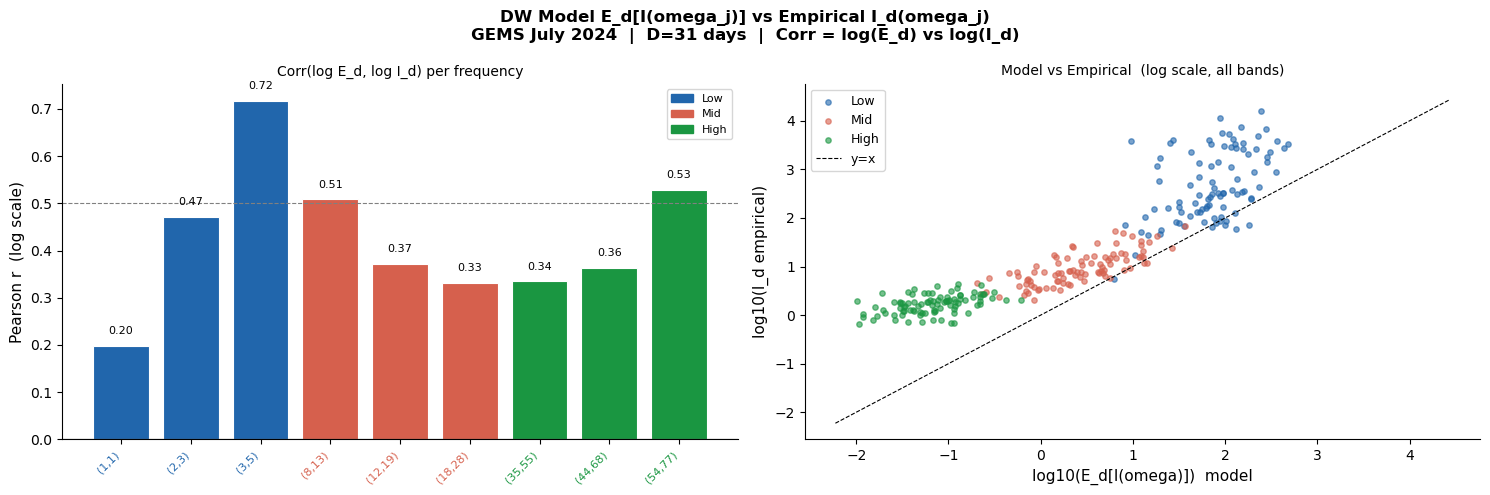

Saved -> /tmp/dw_expected_vs_emp.png


In [16]:
# ── Correlation: E_d[I(omega_j)] vs I_d(omega_j) ────────────────────────────
# For each frequency j: Corr across 31 days of (E_d, I_d)
# For each band: Corr across (j in band) × 31 days

from scipy.stats import pearsonr

# Day-by-day correlation per frequency
corr_per_freq = np.zeros(K)
for q in range(K):
    r, _ = pearsonr(np.log(E_mat[:, q]+1e-12), np.log(I_mat[:, q]+1e-12))
    corr_per_freq[q] = r

# ─── Figure 1: Corr(E_d, I_d) per frequency ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(
    f'DW Model E_d[I(omega_j)] vs Empirical I_d(omega_j)\n'
    f'GEMS July 2024  |  D={N_DAYS} days  |  Corr = log(E_d) vs log(I_d)',
    fontsize=12, fontweight='bold')

ax = axes[0]
cols = [band_colors[b] for b in BAND_LABELS]
bars = ax.bar(range(K), corr_per_freq, color=cols, edgecolor='white', linewidth=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.axhline(0.5, color='gray', lw=0.8, ls='--', label='r=0.5')
ax.set_xticks(range(K))
ax.set_xticklabels([f'({j[0]},{j[1]})' for j in FREQ_ALL], rotation=45, ha='right', fontsize=8)
for q, tc in enumerate(tick_colors):
    ax.get_xticklabels()[q].set_color(tc)
for i, v in enumerate(corr_per_freq):
    ax.text(i, v + 0.02*(1 if v>=0 else -1), f'{v:.2f}',
            ha='center', va='bottom' if v>=0 else 'top', fontsize=8)
ax.set_ylabel('Pearson r  (log scale)', fontsize=11)
ax.set_title('Corr(log E_d, log I_d) per frequency', fontsize=10)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=b) for b,c in band_colors.items()], fontsize=8)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# ─── Figure 2: E_d vs I_d scatter per band ───────────────────────────────────
ax2 = axes[1]
for band_name, b_idx in [('Low',[0,1,2]),('Mid',[3,4,5]),('High',[6,7,8])]:
    e_vals = E_mat[:, b_idx].ravel()
    i_vals = I_mat[:, b_idx].ravel()
    mask = (e_vals > 0) & (i_vals > 0)
    ax2.scatter(np.log10(e_vals[mask]), np.log10(i_vals[mask]),
               s=15, alpha=0.6, color=band_colors[band_name], label=band_name)
    r, _ = pearsonr(np.log(e_vals[mask]), np.log(i_vals[mask]))
    print(f'{band_name:6s}: Corr(log E, log I) = {r:.4f}  '
          f'n={mask.sum()}  '
          f'E_range=[{e_vals[mask].min():.2f},{e_vals[mask].max():.2f}]  '
          f'I_range=[{i_vals[mask].min():.2f},{i_vals[mask].max():.2f}]')
lims = [min(ax2.get_xlim()[0], ax2.get_ylim()[0]),
        max(ax2.get_xlim()[1], ax2.get_ylim()[1])]
ax2.plot(lims, lims, 'k--', lw=0.8, label='y=x')
ax2.set_xlabel('log10(E_d[I(omega)])  model', fontsize=11)
ax2.set_ylabel('log10(I_d empirical)', fontsize=11)
ax2.set_title('Model vs Empirical  (log scale, all bands)', fontsize=10)
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/tmp/dw_expected_vs_emp.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved -> /tmp/dw_expected_vs_emp.png')


Low  : median(E/I)=0.209  mean(E/I)=0.341  std=0.432
Mid  : median(E/I)=0.297  mean(E/I)=0.362  std=0.257
High : median(E/I)=0.041  mean(E/I)=0.054  std=0.046


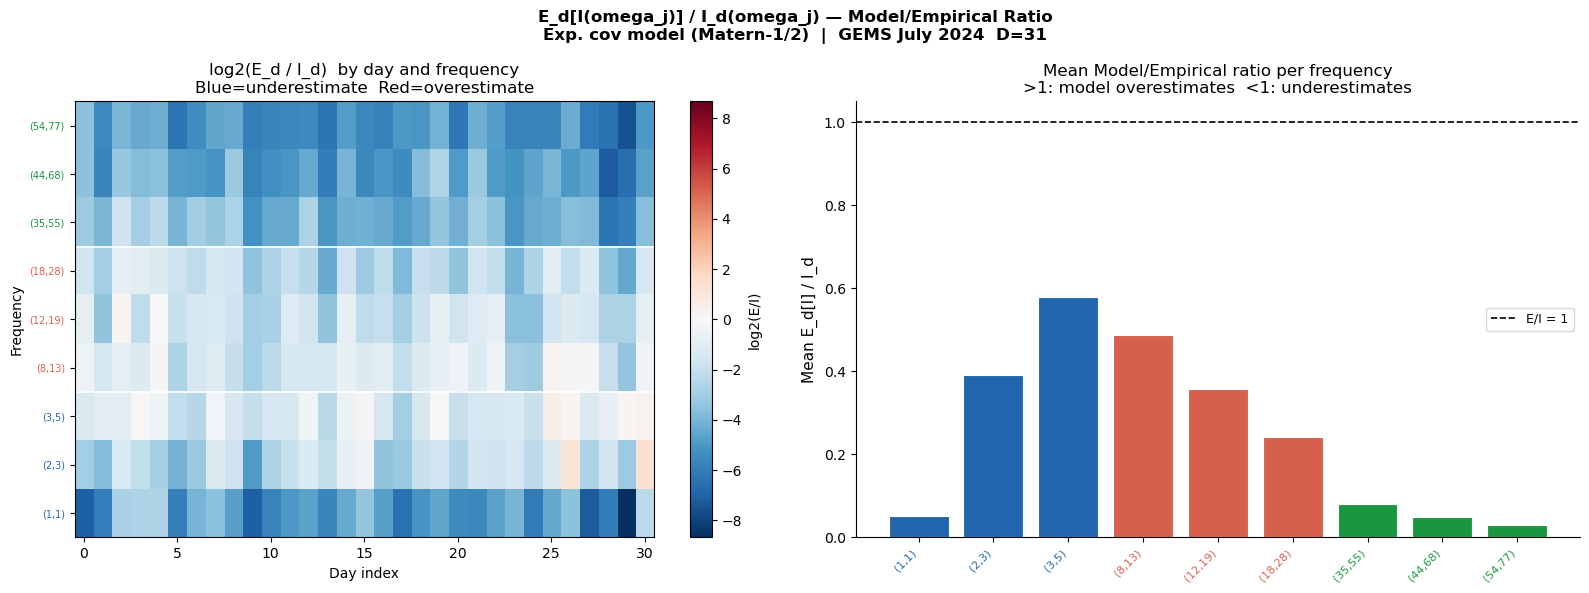

In [17]:
# ── E/I ratio heatmap: days × frequencies ────────────────────────────────────
# Ratio > 1: model overestimates power
# Ratio < 1: model underestimates power
# Pattern by band reveals where the exponential model fits vs. fails

ratio_mat = E_mat / (I_mat + 1e-12)   # (31, 9)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    f'E_d[I(omega_j)] / I_d(omega_j) — Model/Empirical Ratio\n'
    f'Exp. cov model (Matern-1/2)  |  GEMS July 2024  D={N_DAYS}',
    fontsize=12, fontweight='bold')

# (a) Heatmap: days × frequencies
ax = axes[0]
log_ratio = np.log2(ratio_mat + 1e-12)
rlim = np.abs(log_ratio).max()
im = ax.imshow(log_ratio.T, cmap='RdBu_r', vmin=-rlim, vmax=rlim,
               aspect='auto', origin='lower')
plt.colorbar(im, ax=ax, label='log2(E/I)')
ax.set_yticks(range(K))
ax.set_yticklabels([f'({j[0]},{j[1]})' for j in FREQ_ALL], fontsize=7)
for q, tc in enumerate(tick_colors):
    ax.get_yticklabels()[q].set_color(tc)
ax.set_xlabel('Day index'); ax.set_ylabel('Frequency')
ax.set_title('log2(E_d / I_d)  by day and frequency\n'
             'Blue=underestimate  Red=overestimate')
for sep in [2.5, 5.5]:
    ax.axhline(sep, color='white', lw=1.2)

# (b) Mean ratio per band (bar chart)
ax2 = axes[1]
band_ratio_mean = {}
band_ratio_std  = {}
for band, b_idx in [('Low',[0,1,2]),('Mid',[3,4,5]),('High',[6,7,8])]:
    vals = ratio_mat[:, b_idx].ravel()
    band_ratio_mean[band] = np.median(vals)
    band_ratio_std[band]  = np.std(vals)
    print(f'{band:5s}: median(E/I)={np.median(vals):.3f}  '
          f'mean(E/I)={np.mean(vals):.3f}  std={np.std(vals):.3f}')

bands_list = ['Low','Mid','High']
x = np.arange(K)
ax2.bar(x, ratio_mat.mean(axis=0),
        color=[band_colors[b] for b in BAND_LABELS],
        edgecolor='white', linewidth=0.8)
ax2.axhline(1.0, color='black', lw=1.2, ls='--', label='E/I = 1')
ax2.set_xticks(range(K))
ax2.set_xticklabels([f'({j[0]},{j[1]})' for j in FREQ_ALL],
                    rotation=45, ha='right', fontsize=8)
for q, tc in enumerate(tick_colors):
    ax2.get_xticklabels()[q].set_color(tc)
ax2.set_ylabel('Mean E_d[I] / I_d', fontsize=11)
ax2.set_title('Mean Model/Empirical ratio per frequency\n'
              '>1: model overestimates  <1: underestimates')
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/tmp/dw_ratio_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()
